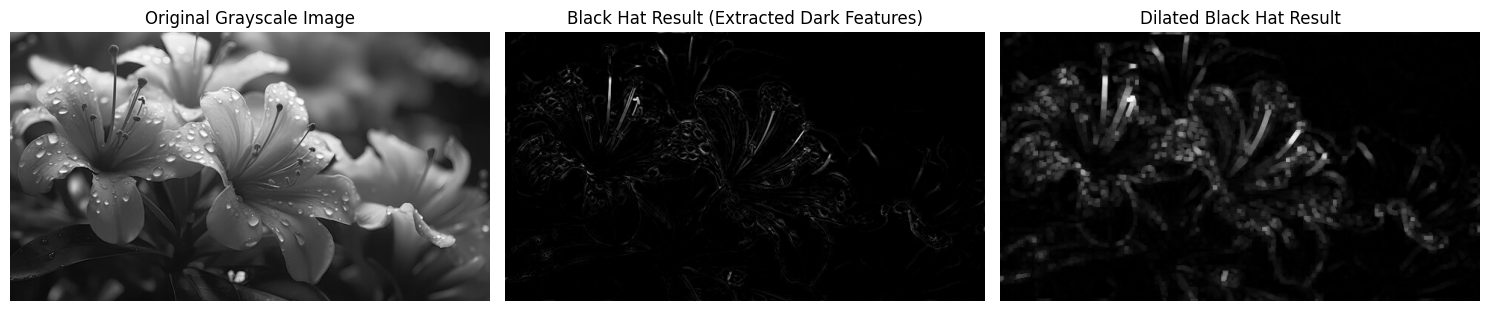

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the uploaded image 'Flower.jpg'
img_original_color = cv2.imread('/content/Flower.jpg')

# Check if image was loaded successfully
if img_original_color is None:
    print("Error: Could not load image 'Flower.jpg'. Please ensure it's in the /content/ directory.")
else:
    # Convert the image to grayscale, as morphological operations usually work best on single-channel images
    img_original = cv2.cvtColor(img_original_color, cv2.COLOR_BGR2GRAY)

    # Define a kernel (structuring element) for morphological operations
    # A 5x5 rectangular kernel is commonly used. You can experiment with different sizes/shapes.
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

    # 1. Apply Black Hat morphological operation
    # Black Hat = Closing(Image) - Image. It extracts dark features on a bright background.
    # The output will have bright pixels where dark features were extracted, and a dark background.
    blackhat_result = cv2.morphologyEx(img_original, cv2.MORPH_BLACKHAT, kernel)

    # 2. To 'dilate the foreground regions' (i.e., the features extracted by black hat),
    # we apply dilation on the `blackhat_result`. This will enlarge the bright spots
    # that represent the extracted dark features.
    dilated_blackhat = cv2.dilate(blackhat_result, kernel, iterations=1)

    # Display the images
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_original, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(blackhat_result, cmap='gray')
    plt.title('Black Hat Result (Extracted Dark Features)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(dilated_blackhat, cmap='gray')
    plt.title('Dilated Black Hat Result')
    plt.axis('off')

    plt.tight_layout()
    plt.show()